In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.special import airy
from dataclasses import dataclass, field


## Preliminaries

In [16]:
@dataclass
class CTRParameters:
    #Container for constants, user-set parameters, and derived grids

    #Physical constants
    c: float = 299792458.0
    e: float = 1.60217663e-19
    eps0: float = 8.854187812e-12
    m_e_MeV: float = 0.51099895

    #Energy parameters
    E_MeV: float = 100  # Code assumes energy is entered in MeV

    #Charge parameters
    bunchcharge: float = 5e-12

    #Transverse beam parameters - OAM + Gaussian, in meters
    sigma_x: float = 100e-6
    sigma_y: float = 100e-6

    #Temporal pulse, in seconds
    sigma_t: float = 1e-12

    #Observation-grid sizes
    Nangle: int = 1000
    Nlam: int = 1000

    #Spatial-grid sizes
    Nspace: int = 1000

    #Wavelength and angular ranges
    theta_min: float = -0.2
    theta_max: float = 0.2
    lambda_min: float = 1e-6
    lambda_max: float = 1e-5

    #Airy-beam parameters
    #Minimum propagation distance of Airy-beam
    airy_z_min: float = 0.0
    #Maximum propagation distance of Airy-beam
    airy_z_max: float = 0.0001
    #Apodization level
    airy_a: float = 0.05

    #The following fields are calculated automatically in __post_init__.
    E_total: float = field(init=False)
    gamma: float = field(init=False)
    beta: float = field(init=False)
    v: float = field(init=False)
    Ne: float = field(init=False)
    sigma_z: float = field(init=False)

    th: np.ndarray = field(init=False)
    lam: np.ndarray = field(init=False)
    TH: np.ndarray = field(init=False)
    LAM: np.ndarray = field(init=False)
    phi: np.ndarray = field(init=False)
    omega: np.ndarray = field(init=False)

    x: np.ndarray = field(init=False)
    y: np.ndarray = field(init=False)
    z: np.ndarray = field(init=False)

    x_airy: np.ndarray = field(init=False)
    z_airy: np.ndarray = field(init=False)

    W1: np.ndarray = field(init=False)

    def __post_init__(self):
        #Compute derived physical parameters and numerical grids

        #Relativistic energy quantities.
        self.E_total = self.E_MeV + self.m_e_MeV
        self.gamma = self.E_total/self.m_e_MeV
        self.beta = np.sqrt(1 - 1 / self.gamma**2)
        self.v = self.beta*self.c

        #Number of electrons in the bunch
        self.Ne = self.bunchcharge/self.e

        #Convert temporal bunch length to longitudinal bunch length
        self.sigma_z = self.c*self.sigma_t

        #Observation grids
        self.th = np.linspace(self.theta_min, self.theta_max, self.Nangle)
        self.lam = np.linspace(self.lambda_min, self.lambda_max, self.Nlam)
        self.TH, self.LAM = np.meshgrid(self.th, self.lam, indexing='ij')
        self.phi = np.linspace(0, 2*np.pi, self.Nangle, endpoint=False)
        self.omega = 2*np.pi*self.c/self.lam

        #Single-electron spectrum
        A = self.e**2 / (4*np.pi * self.eps0 * self.c)
        self.W1 = A*(self.beta**2 * np.sin(self.TH)**2) / (1.0 - self.beta**2 * np.cos(self.TH)**2)**2

        #Spatial electron-distribution grids
        #Adjust constants to play with resolution
        self.x = np.linspace(-self.sigma_x, self.sigma_x, self.Nspace)
        self.y = np.linspace(-self.sigma_y, self.sigma_y, self.Nspace)
        self.z = np.linspace(-8*self.sigma_z, 8*self.sigma_z, self.Nspace)

        #Airy distribution grids
        #Adjust constants to play with resolution
        self.x_airy = np.linspace(-8*self.sigma_x, 8*self.sigma_x, self.Nspace)
        self.z_airy = np.linspace(self.airy_z_min, self.airy_z_max, self.Nspace)


In [ ]:
class ElectronDistributions:
    #Build electron-density profiles used in the CTR calculation

    @staticmethod
    def build_rho_gaussian(x, y, z, sigma_x, sigma_z):
        #Build the Gaussian electron distribution

        r2 = x**2 + y**2
        return np.exp((-(r2)/(2*sigma_x**2)) - (z**2 / (2*sigma_z**2)))

    @staticmethod
    def build_rho_oam(x, y, z, sigma_x, sigma_z, l):
        #Build the OAM-like electron distribution

        r2 = x**2 + y**2
        return (r2**l) * np.exp((-(r2) / (2*sigma_x**2)) - (z**2 / (2*sigma_z**2)))

    @staticmethod
    def build_airy_beam_scaled(x, z, wavelength, x0, a=0.05):
        #Build the finite-energy Airy beam profile

        k = 2*np.pi/wavelength
        X, Z = np.meshgrid(x, z, indexing='ij')
        s = X/x0
        xi = z/(k*x0**2)
        arg = s - (xi**2)/4 + 1j*a*xi
        Ai, _, _, _ = airy(arg)
        phase = (s*xi)/2 - (xi**3)/12 + (xi*a**2)/2
        amp = a*(s - (xi**2)/2)
        psi = Ai * np.exp(amp + 1j*phase)
        return psi, xi

    def __init__(self, params):
        #Store the shared CTR parameters
        self.params = params

    def gaussian(self):
        #Return the Gaussian distribution on the configured grid
        p = self.params
        return self.build_rho_gaussian(p.x, p.y, p.z, p.sigma_x, p.sigma_z)

    def oam(self, l=2):
        #Return the OAM distribution for the chosen topological order l
        p = self.params
        return self.build_rho_oam(p.x, p.y, p.z, p.sigma_x, p.sigma_z, l=l)

    def airy_intensity(self):
        #Return the Airy intensity profile used as rho_z in the solver
        p = self.params
        psi, xi = self.build_airy_beam_scaled(p.x_airy, p.z_airy, p.lam, p.sigma_x, a=p.airy_a)
        rho_airy = np.abs(psi[0])**2
        return rho_airy, xi


In [18]:
class CTRSolver:
    #Compute the form factor and CTR bunch spectrum

    def __init__(self, params):
        #Store shared parameters and constants
        self.params = params

    def f2(self, omega, theta, rho_z, z, beta):
        #Calculate the longitudinal form factor.

        #Step size
        dz = z[1] - z[0]

        #Normalize the supplied longitudinal density
        rho = rho_z / np.trapezoid(rho_z, z)

        #Fourier transform rho(z) into R(k_z)
        Rk = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(rho))) * dz
        kz = np.fft.fftshift(2*np.pi*np.fft.fftfreq(z.size, d=dz))

        #Normalize so that |R(k_z=0)|^2 = 1
        Rk /= Rk[np.argmin(np.abs(kz))]

        #CTR target longitudinal wave-vector mismatch
        k = omega / self.params.c
        kz_target = k[None, :] * (1.0/beta - np.cos(theta)[:, None])

        #Interpolate |R(k_z)|^2 onto the target grid
        kz_flat = np.clip(kz_target.ravel(), kz[0], kz[-1])
        f2 = np.interp(kz_flat, kz, np.abs(Rk)**2).reshape(kz_target.shape)
        return f2

    def electron_bunch_spectrum(self, W1, Ne, omega, th, rho_z, z, beta):
        #Calculate the coherent + incoherent bunch spectrum
        Wn_list = []
        F2 = self.f2(omega, th, rho_z, z, beta)
        Wn_list.append(W1 * (Ne + Ne*(Ne-1)*F2))

        # Color-scale helper values for plotting.
        stack = np.stack(Wn_list, axis=0)
        positive = stack[stack > 0]
        vmin = np.percentile(positive, 1) if positive.size else 1e-30
        vmax = stack.max()
        return Wn_list, vmin, vmax, F2

    def solve_for_density(self, rho_z):
        #Solving spectrum for one density using configured grids
        p = self.params
        return self.electron_bunch_spectrum(p.W1, p.Ne, p.omega, p.th, rho_z, p.z, p.beta)


In [19]:
class CTRPlotter:
    #Plot CTR spectra and integrated photon-count curves

    @staticmethod
    def plot_ctr_spectrum(th, lam, Wn_list, vmin, vmax, title='CTR'):
        #Plot a 2D CTR spectrum with logarithmic color normalization
        
        fig, ax = plt.subplots()

        # Wn_list[0] has axes theta x wavelength. Transpose so wavelength is y.
        im = ax.pcolormesh(th, lam, np.maximum(Wn_list[0].T, vmin), shading='auto', cmap='inferno', norm=LogNorm(vmin=vmin, vmax=vmax))

        ax.set_title(title)
        ax.set_xlabel(r'$\theta$ (rad)')
        ax.set_ylabel(r'$\lambda$ (m)')
        ax.set_ylim(lam.min(), lam.max())

        cb = plt.colorbar(im, ax=ax)
        cb.set_label(r'$W_n$ (LogNorm)')
        return fig, ax

    @staticmethod
    def integrate_Wn_over_Omega(Wn_list, th, TH, lam, title='Photon Count', logscale=True):
        #Integrate Wn over solid angle and plot photon count vs wavelength.

        jac = 2 * np.pi * np.sin(TH)
        Wn_int = [np.trapezoid(np.abs(Wn * jac), th, axis=0) for Wn in Wn_list]
        Wn_int_array = np.array(Wn_int)

        plt.figure()
        for i, spectrum in enumerate(Wn_int_array):
            plt.plot(lam, spectrum)

        if logscale:
            plt.yscale('log')

        plt.xlabel(r'$\lambda$ [m]')
        plt.ylabel('Photon Count (Scaled)')
        plt.title(title)
        return Wn_int_array


In [20]:
class CTRSimulation:
    #High-level object that coordinates distributions, spectra, and plots

    def __init__(self, params=None):
        #Create a complete CTR simulation object
        self.params = params if params is not None else CTRParameters()
        self.distributions = ElectronDistributions(self.params)
        self.solver = CTRSolver(self.params)
        self.plotter = CTRPlotter()

        # These dictionaries store generated densities and spectrum results
        self.rhos = {}
        self.results = {}

    def build_distributions(self, oam_l=2):
        #Build Gaussian, OAM, and Airy density profiles
        self.rhos['gaussian'] = self.distributions.gaussian()
        self.rhos['oam'] = self.distributions.oam(l=oam_l)

        rho_airy, xi = self.distributions.airy_intensity()
        self.rhos['airy'] = rho_airy
        self.airy_xi = xi
        return self.rhos

    def compute_spectra(self):
        #Compute Wn, plotting limits, and form factors for all stored densities
        p = self.params

        for name, rho_z in self.rhos.items():
            self.results[name] = self.solver.electron_bunch_spectrum(p.W1, p.Ne, p.omega, p.th, rho_z, p.z, p.beta)
        return self.results

    def plot_spectrum(self, name, title=None):
        #Plot the 2D CTR spectrum for one named density
        p = self.params
        Wn_list, vmin, vmax, F2 = self.results[name]
        title = title if title is not None else f'CTR from {name}'
        return self.plotter.plot_ctr_spectrum(p.th, p.lam, Wn_list, vmin, vmax, title=title)

    def plot_integrated_photon_count(self, name, title=None, logscale=True):
        #Plot the angle-integrated photon count for one named density
        p = self.params
        Wn_list, vmin, vmax, F2 = self.results[name]
        title = title if title is not None else f'Photon Count from {name} CTR'
        return self.plotter.integrate_Wn_over_Omega(Wn_list, p.th, p.TH, p.lam, title=title, logscale=logscale)


In [21]:
#Initialize the simulation with the default parameters above
sim = CTRSimulation()
p = sim.params

#Build the same three distributions used in the original notebook
sim.build_distributions(oam_l=2)

#Compute the CTR spectrum for Gaussian, OAM, and Airy profiles
sim.compute_spectra()

#Cleaning up variable names for clarity
rho_gaussian = sim.rhos['gaussian']
rho_oam = sim.rhos['oam']
rho_airy = sim.rhos['airy']

Wn_list_gaussian, vmin_gaussian, vmax_gaussian, F2_gaussian = sim.results['gaussian']
Wn_list_oam, vmin_oam, vmax_oam, F2_oam = sim.results['oam']
Wn_list_airy, vmin_airy, vmax_airy, F2_airy = sim.results['airy']


## Plotting Coherent Transition Radiation Spectra


(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'CTR from Gaussian Distribution \n Temporal Length = 1e-12 s'}, xlabel='$\\theta$ (rad)', ylabel='$\\lambda$ (m)'>)

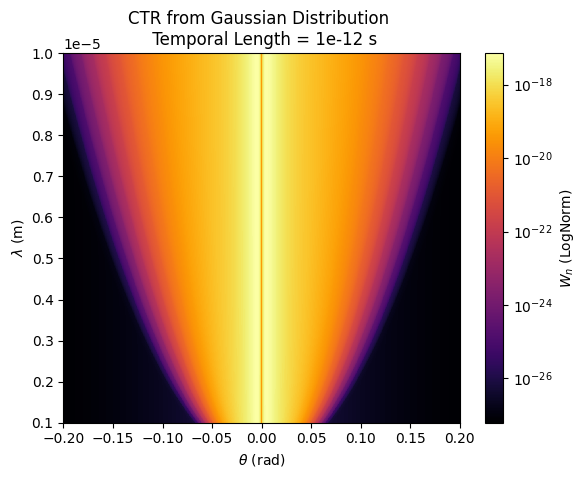

In [22]:
sim.plot_spectrum('gaussian',title=f'CTR from Gaussian Distribution \n Temporal Length = {p.sigma_t} s')


(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'CTR from OAM Distribution \n Temporal Length = 1e-12 s'}, xlabel='$\\theta$ (rad)', ylabel='$\\lambda$ (m)'>)

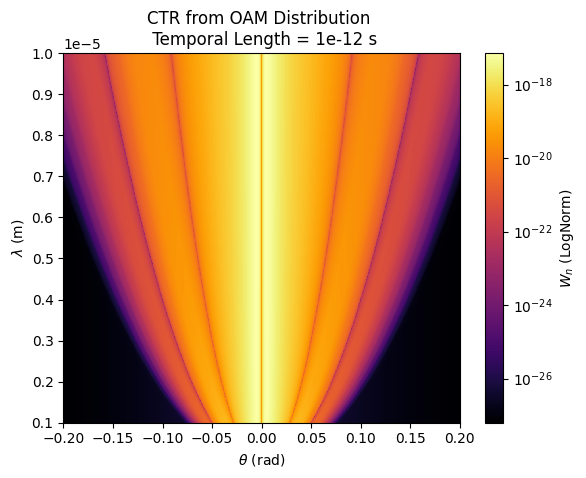

In [23]:
sim.plot_spectrum('oam', title=f'CTR from OAM Distribution \n Temporal Length = {p.sigma_t} s')


(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'CTR from Airy Distribution \n Propagation Distance = 0.0001 m'}, xlabel='$\\theta$ (rad)', ylabel='$\\lambda$ (m)'>)

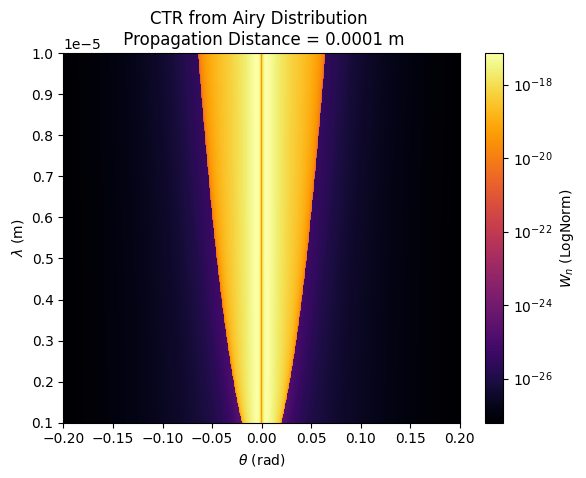

In [24]:
sim.plot_spectrum('airy', title=f'CTR from Airy Distribution \n Propagation Distance = {p.z_airy[-1] - p.z_airy[0]} m')


## Plotting the angle-integrated photon counts


array([[1.15172670e-20, 1.15571045e-20, 1.15965649e-20, 1.16356104e-20,
        1.16746169e-20, 1.17130981e-20, 1.17512983e-20, 1.17891637e-20,
        1.18267045e-20, 1.18641839e-20, 1.19010666e-20, 1.19377507e-20,
        1.19741637e-20, 1.20103543e-20, 1.20462312e-20, 1.20818168e-20,
        1.21170581e-20, 1.21522014e-20, 1.21870644e-20, 1.22215107e-20,
        1.22558519e-20, 1.22897382e-20, 1.23237273e-20, 1.23572772e-20,
        1.23904804e-20, 1.24236000e-20, 1.24564290e-20, 1.24890982e-20,
        1.25215300e-20, 1.25536236e-20, 1.25855870e-20, 1.26173289e-20,
        1.26489205e-20, 1.26801850e-20, 1.27112891e-20, 1.27421256e-20,
        1.27728746e-20, 1.28034932e-20, 1.28335941e-20, 1.28638070e-20,
        1.28936999e-20, 1.29233729e-20, 1.29530822e-20, 1.29823147e-20,
        1.30114601e-20, 1.30404571e-20, 1.30692983e-20, 1.30979724e-20,
        1.31264275e-20, 1.31546701e-20, 1.31827732e-20, 1.32107511e-20,
        1.32386087e-20, 1.32661765e-20, 1.32936277e-20, 1.332095

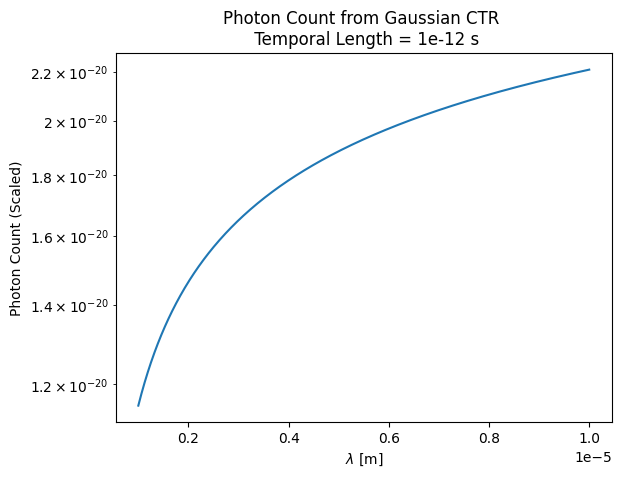

In [25]:
sim.plot_integrated_photon_count('gaussian', title=f'Photon Count from Gaussian CTR \n Temporal Length = {p.sigma_t} s')


array([[8.33643360e-21, 8.37227740e-21, 8.40773480e-21, 8.44395978e-21,
        8.47848214e-21, 8.51354376e-21, 8.54832942e-21, 8.58281642e-21,
        8.61664559e-21, 8.65080553e-21, 8.68453208e-21, 8.71746962e-21,
        8.75117347e-21, 8.78413746e-21, 8.81646020e-21, 8.84910382e-21,
        8.88173760e-21, 8.91322336e-21, 8.94515965e-21, 8.97705188e-21,
        9.00818145e-21, 9.03937581e-21, 9.07045772e-21, 9.10107932e-21,
        9.13153810e-21, 9.16193725e-21, 9.19248785e-21, 9.22191957e-21,
        9.25185681e-21, 9.28162735e-21, 9.31097374e-21, 9.33981323e-21,
        9.36920884e-21, 9.39813012e-21, 9.42638422e-21, 9.45520991e-21,
        9.48354683e-21, 9.51145632e-21, 9.53946063e-21, 9.56739401e-21,
        9.59508050e-21, 9.62244050e-21, 9.64960322e-21, 9.67705426e-21,
        9.70408592e-21, 9.73033347e-21, 9.75759640e-21, 9.78403427e-21,
        9.81030251e-21, 9.83645633e-21, 9.86285563e-21, 9.88879014e-21,
        9.91409040e-21, 9.94014034e-21, 9.96567445e-21, 9.990975

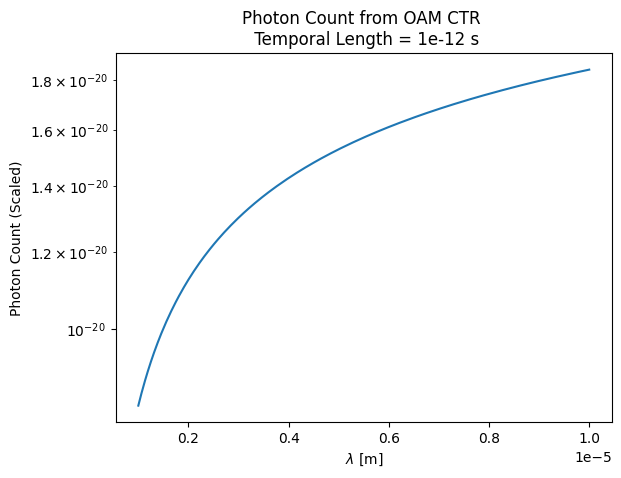

In [26]:
sim.plot_integrated_photon_count('oam', title=f'Photon Count from OAM CTR \n Temporal Length = {p.sigma_t} s')


array([[5.06874255e-21, 5.10103085e-21, 5.13358590e-21, 5.16556981e-21,
        5.19699747e-21, 5.22811453e-21, 5.25988060e-21, 5.29110827e-21,
        5.32181109e-21, 5.35200221e-21, 5.38277586e-21, 5.41330456e-21,
        5.44333686e-21, 5.47288477e-21, 5.50242411e-21, 5.53230492e-21,
        5.56171517e-21, 5.59066589e-21, 5.61916775e-21, 5.64824349e-21,
        5.67707513e-21, 5.70546993e-21, 5.73343773e-21, 5.76124389e-21,
        5.78953599e-21, 5.81741203e-21, 5.84488112e-21, 5.87195211e-21,
        5.89920837e-21, 5.92659923e-21, 5.95360157e-21, 5.98022359e-21,
        6.00647327e-21, 6.03313134e-21, 6.05969592e-21, 6.08589659e-21,
        6.11174080e-21, 6.13723575e-21, 6.16325497e-21, 6.18905945e-21,
        6.21452215e-21, 6.23964981e-21, 6.26444901e-21, 6.28979531e-21,
        6.31489841e-21, 6.33967969e-21, 6.36414527e-21, 6.38830117e-21,
        6.41294624e-21, 6.43740028e-21, 6.46155055e-21, 6.48540266e-21,
        6.50896211e-21, 6.53288263e-21, 6.55673439e-21, 6.580298

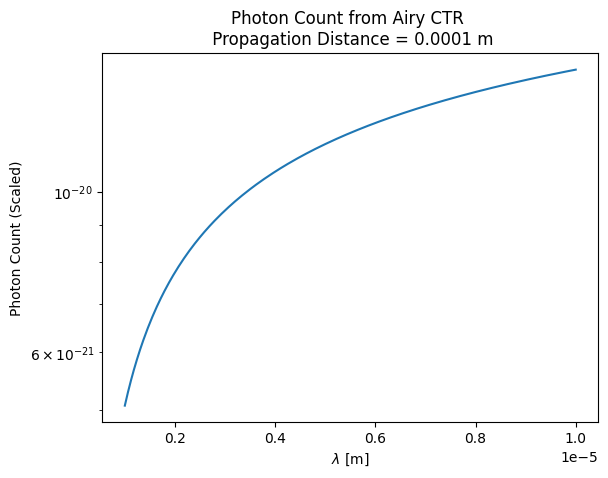

In [27]:
sim.plot_integrated_photon_count('airy', title=f'Photon Count from Airy CTR \n Propagation Distance = {p.z_airy[-1]} m')
